# Wildfire Risk Assessment — Fire Weather Index (FWI) Risk
**Kazakhstan adaptation of the CLIMAAX FIRE/FWI Risk workflow**

This notebook follows the hazard notebook (`wildfire_FWI_hazard_KAZ.py`) and
produces a wildfire risk assessment by combining:
  - **Fire danger** = seasonal FWI (from hazard notebook) + burnable vegetation fraction
  - **Vulnerability** = population density, WUI proxy, protected areas, biomass
  - **Risk** = Pareto analysis of danger × vulnerability indicators

---
## Data Substitutions

| Original CLIMAAX | Kazakhstan Replacement |
|---|---|
| NUTS admin regions (GISCO API) | Kazakhstan OSM shapefile (local) |
| CDS `sis-tourism-fire-danger-indicators` seasonal FWI | FWI stats loaded from hazard notebook cache |
| EURO-CORDEX rotated-pole grid | ISIMIP3b regular lat/lon 0.5° grid |
| ESA-CCI Land Cover 300m (CDS, requires account) | ESA WorldCover 2021 v2.0 10m (direct download) |
| EFFIS Burnable Area — Europe only | Burnable fraction computed from ESA WorldCover |
| EFFIS WUI population — Europe only | WorldPop 2020 masked to burnable WorldCover cells |
| EFFIS Protected Areas — Europe only | WDPA (free registration at protectedplanet.net) |
| EFFIS Ecosystem Irreplaceability — Europe only | ESA CCI Above-Ground Biomass 2020 (free, CEDA) |
| EFFIS Restoration Cost — Europe only | ESA CCI Biomass (proxy: higher biomass = higher cost) |
| RCP scenarios | SSP scenarios from hazard notebook |

---
## Notes

**FWI threshold for danger**: pixels where mean seasonal FWI < `FWI_DANGER_THRESH`
are treated as climatically low-danger and excluded from the danger index.
The default of 20 matches the original workflow. Adjust to local conditions.

**Non-burnable classes**: ESA WorldCover classes 50 (built-up), 60 (bare/sparse),
70 (snow/ice), 80 (water), 90 (wetland), 100 (moss) are treated as non-burnable.
Cropland (class 40) is treated as **burnable** for Kazakhstan — stubble and
steppe-edge fires are a documented hazard in agricultural oblasts.

**WDPA and ESA CCI Biomass**: both require free (no-cost) registration.
Download instructions and skip logic are provided. The Pareto analysis
runs on whichever indicators are available.

In [2]:
import gc
import math
import pathlib

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds as rio_from_bounds
from rioxarray.merge import merge_arrays
import requests
import pooch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from paretoset import paretoset
from tqdm import tqdm

print('Libraries loaded.')

Libraries loaded.


## Configuration
Must match settings used in the hazard notebook.

In [3]:
region_name     = 'East Kazakhstan Region'
region_id       = 'KAZ_EKO'
oblast_en       = 'East Kazakhstan Region'
BBOX_BUFFER     = 0.5

MODELS          = ['GFDL-ESM4']   # extend to 5 GCMs for production
HIST_START      = 1985
HIST_END        = 2014
FUTURE_SCENARIO = 'ssp370'
FUTURE_START    = 2041
FUTURE_END      = 2050

FWI_DANGER_THRESH = 20

NON_BURNABLE_CLASSES = [50, 60, 70, 80, 90, 100]

## Paths

In [4]:
KAZ_SHP = pathlib.Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)

work_dir     = pathlib.Path('.')
data_dir     = work_dir / 'data'
results_dir  = work_dir / 'results'
cache_dir    = data_dir / 'isimip_clipped'   
vuln_dir     = data_dir / 'vulnerability'
esa_wc_dir   = data_dir / 'esa_wc_tiles'

for d in [results_dir, vuln_dir, esa_wc_dir]:
    d.mkdir(parents=True, exist_ok=True)

## Load region boundary

In [5]:
kaz_gdf  = gpd.read_file(KAZ_SHP)
eko_gdf  = kaz_gdf[kaz_gdf['oblast_en'] == oblast_en].copy()
if eko_gdf.empty:
    raise ValueError(f"'{oblast_en}' not found. "
                     f"Available: {sorted(kaz_gdf['oblast_en'].unique())}")
eko_dissolved = eko_gdf.dissolve().reset_index(drop=True)

minx, miny, maxx, maxy = eko_dissolved.total_bounds
LON_MIN = minx - BBOX_BUFFER
LON_MAX = maxx + BBOX_BUFFER
LAT_MIN = miny - BBOX_BUFFER
LAT_MAX = maxy + BBOX_BUFFER
bbox = [LON_MIN, LAT_MIN, LON_MAX, LAT_MAX]   

print(f'Region: {oblast_en}')
print(f'Bbox: lon [{LON_MIN:.2f}, {LON_MAX:.2f}]  lat [{LAT_MIN:.2f}, {LAT_MAX:.2f}]')

Region: East Kazakhstan Region
Bbox: lon [80.61, 87.82]  lat [46.36, 51.52]


## Load FWI statistics from hazard notebook

The hazard notebook saves annual FWI statistics per model × scenario as
`data/isimip_clipped/fwi_stats_*.nc`. We load and average those here.
**Run the hazard notebook first** if these files do not exist.

In [6]:
def load_fwi_stats(scenario, year_start, year_end):
    """Load seasonal_mean DataArrays for all available models."""
    arrays = []
    for model in MODELS:
        p = (cache_dir /
             f"fwi_stats_{model.lower()}_{scenario}_{year_start}_{year_end}.nc")
        if not p.exists():
            print(f'  MISSING: {p.name} — run hazard notebook first.')
            continue
        ds = xr.open_dataset(p)
        arrays.append(ds['seasonal_mean'].assign_coords(model=model)
                      .expand_dims('model'))
        ds.close()
    if not arrays:
        raise FileNotFoundError(
            'No FWI stats found. Run wildfire_FWI_hazard_KAZ.py first.')
    stack = xr.concat(arrays, dim='model')
    return stack


print('Loading historical FWI stats...')
hist_seas_stack = load_fwi_stats('historical', HIST_START, HIST_END)

print('Loading future FWI stats...')
fut_seas_stack = load_fwi_stats(FUTURE_SCENARIO, FUTURE_START, FUTURE_END)

hist_fwi = hist_seas_stack.mean(dim=['model', 'year'])
fut_fwi  = fut_seas_stack.mean(dim=['model', 'year'])

lats = hist_fwi.lat.values
lons = hist_fwi.lon.values

print(f'FWI grid: {len(lats)} lat × {len(lons)} lon cells')

Loading historical FWI stats...
Loading future FWI stats...
FWI grid: 10 lat × 15 lon cells


## ESA WorldCover 2021 — burnable fraction

Each 0.5° FWI grid cell is assigned the fraction of its area covered by
burnable vegetation classes, computed from ESA WorldCover 10m data
(resampled to 100m for memory efficiency, then aggregated to 0.5°).

In [7]:
ESA_WC_BASE = 'https://esa-worldcover.s3.amazonaws.com/v200/2021/map'

def esa_wc_tiles_for_bbox(bbox_wsen):
    w, s, e, n = bbox_wsen
    tiles = []
    for lat in range(int(math.floor(s / 3)) * 3,
                     int(math.ceil(n  / 3)) * 3, 3):
        for lon in range(int(math.floor(w / 3)) * 3,
                         int(math.ceil(e  / 3)) * 3, 3):
            ns = f'N{lat:02d}' if lat >= 0 else f'S{abs(lat):02d}'
            ew = f'E{lon:03d}' if lon >= 0 else f'W{abs(lon):03d}'
            tiles.append(f'{ns}{ew}')
    return tiles


def download_esa_wc_tile(tile_name, dest):
    fname    = f'ESA_WorldCover_10m_2021_v200_{tile_name}_Map.tif'
    out_path = dest / fname
    if out_path.exists():
        print(f'  Cached: {fname}')
    else:
        pooch.retrieve(url=f'{ESA_WC_BASE}/{fname}',
                       known_hash=None, path=dest, fname=fname)
        print(f'  Downloaded: {fname}')
    return out_path


tile_names  = esa_wc_tiles_for_bbox(bbox)
print(f'WorldCover tiles needed: {tile_names}')
tile_paths  = [download_esa_wc_tile(t, esa_wc_dir) for t in tile_names]

WorldCover tiles needed: ['N45E078', 'N45E081', 'N45E084', 'N45E087', 'N48E078', 'N48E081', 'N48E084', 'N48E087', 'N51E078', 'N51E081', 'N51E084', 'N51E087']
  Cached: ESA_WorldCover_10m_2021_v200_N45E078_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N45E081_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N45E084_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N45E087_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E078_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E081_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E084_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E087_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E078_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E081_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E084_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E087_Map.tif


In [8]:
TARGET_DEG = 100 / 111320
out_h = max(1, int((LAT_MAX - LAT_MIN) / TARGET_DEG))
out_w = max(1, int((LON_MAX - LON_MIN) / TARGET_DEG))
print(f'100m clip shape: ({out_h}, {out_w})')

clipped_paths = []
for p in tile_paths:
    out_path = esa_wc_dir / p.name.replace('.tif', '_clipped100m.tif')
    if out_path.exists():
        print(f'  Cached: {out_path.name}')
    else:
        with rasterio.open(p) as src:
            win  = rio_from_bounds(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX,
                                   src.transform)
            data = src.read(1, window=win, out_shape=(out_h, out_w),
                            resampling=Resampling.nearest)
            out_tf = rasterio.transform.from_bounds(
                LON_MIN, LAT_MIN, LON_MAX, LAT_MAX, out_w, out_h)
            with rasterio.open(out_path, 'w', driver='GTiff',
                               height=out_h, width=out_w, count=1,
                               dtype=data.dtype, crs=src.crs,
                               transform=out_tf) as dst:
                dst.write(data, 1)
        print(f'  Saved: {out_path.name}')
    clipped_paths.append(out_path)

100m clip shape: (5735, 8018)
  Cached: ESA_WorldCover_10m_2021_v200_N45E078_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N45E081_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N45E084_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N45E087_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E078_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E081_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E084_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E087_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E078_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E081_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E084_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E087_Map_clipped100m.tif


In [9]:
esa_arrays = [rxr.open_rasterio(p, masked=True) for p in clipped_paths]
if len(esa_arrays) > 1:
    from rioxarray.merge import merge_arrays
    esa_wc = merge_arrays(esa_arrays).squeeze()
else:
    esa_wc = esa_arrays[0].squeeze()
esa_wc.rio.write_crs('EPSG:4326', inplace=True)

lc_vals = esa_wc.values.astype(float)

burnable_100m = ~np.isin(lc_vals, NON_BURNABLE_CLASSES + [255])  

burn_frac = np.full((len(lats), len(lons)), np.nan)
half = 0.25   

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        lat_lo, lat_hi = lat - half, lat + half
        lon_lo, lon_hi = lon - half, lon + half
        y_ok = (esa_wc.y.values >= lat_lo) & (esa_wc.y.values < lat_hi)
        x_ok = (esa_wc.x.values >= lon_lo) & (esa_wc.x.values < lon_hi)
        patch = burnable_100m[np.ix_(y_ok, x_ok)]
        valid = patch[~np.isnan(lc_vals[np.ix_(y_ok, x_ok)])]
        if valid.size > 0:
            burn_frac[i, j] = valid.mean()   

burn_frac_da = xr.DataArray(burn_frac, dims=['lat', 'lon'],
                              coords={'lat': lats, 'lon': lons},
                              name='burn_frac')
print(f'Burnable fraction — min: {np.nanmin(burn_frac):.2f}  '
      f'max: {np.nanmax(burn_frac):.2f}  '
      f'mean: {np.nanmean(burn_frac):.2f}')

Burnable fraction — min: 0.15  max: 1.00  mean: 0.89


## Danger Index

Following the EFFIS/CLIMAAX methodology:
1. Apply FWI danger threshold — pixels below `FWI_DANGER_THRESH` are masked
2. Normalise FWI and burnable fraction with min-max
3. Average equally weighted → danger index [0, 1]

In [10]:
def normalise(da):
    mn, mx = float(da.min(skipna=True)), float(da.max(skipna=True))
    if mx == mn:
        return xr.zeros_like(da)
    return (da - mn) / (mx - mn)


def build_danger(fwi_da, burn_frac_da, thresh):
    fwi_masked  = fwi_da.where(fwi_da >= thresh)
    non_burnable = burn_frac_da < 0.05    # <5% burnable → exclude
    fwi_masked  = fwi_masked.where(~non_burnable)

    fwi_norm  = normalise(fwi_masked)
    burn_norm = normalise(burn_frac_da.where(~non_burnable))
    danger    = (fwi_norm + burn_norm) / 2
    return danger, fwi_masked


danger_hist, fwi_hist_masked = build_danger(hist_fwi, burn_frac_da,
                                             FWI_DANGER_THRESH)
danger_fut,  fwi_fut_masked  = build_danger(fut_fwi,  burn_frac_da,
                                             FWI_DANGER_THRESH)

print('Danger index computed.')
print(f'  Historical — valid cells: {int((~np.isnan(danger_hist.values)).sum())}')
print(f'  Future     — valid cells: {int((~np.isnan(danger_fut.values)).sum())}')

Danger index computed.
  Historical — valid cells: 20
  Future     — valid cells: 31


## Vulnerability Data

### 1. WorldPop 2020 — Population Density
Direct download, no registration required.

In [11]:
wp_path = vuln_dir / 'kaz_ppp_2020.tif'
if not wp_path.exists():
    print('Downloading WorldPop 2020...')
    url = ('https://data.worldpop.org/GIS/Population/'
           'Global_2000_2020/2020/KAZ/kaz_ppp_2020.tif')
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(wp_path, 'wb') as f:
            with tqdm(total=total, unit='B', unit_scale=True,
                      unit_divisor=1024, desc='WorldPop', ncols=80) as pbar:
                for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                    f.write(chunk)
                    pbar.update(len(chunk))
    print(f'Saved: {wp_path.name}')
else:
    print(f'Cached: {wp_path.name}')

Cached: kaz_ppp_2020.tif


In [12]:
def raster_to_fwi_grid(raster_path, lats, lons, resampling=Resampling.average,
                        clip_bbox=None):
    da = rxr.open_rasterio(raster_path, masked=True).squeeze()
    if clip_bbox is not None:
        w, s, e, n = clip_bbox
        da = da.sel(x=slice(w, e), y=slice(n, s))

    target = xr.DataArray(
        np.nan, dims=['y', 'x'],
        coords={'y': lats, 'x': lons}
    ).rio.write_crs('EPSG:4326').rio.set_spatial_dims('x', 'y')

    da_reproj = da.rio.reproject_match(
        target,
        resampling=resampling
    )
    return da_reproj.values.astype(float)


print('Aggregating WorldPop to FWI grid...')
pop_grid = raster_to_fwi_grid(wp_path, lats, lons,
                               resampling=Resampling.sum,
                               clip_bbox=bbox)
pop_da = xr.DataArray(pop_grid, dims=['lat', 'lon'],
                       coords={'lat': lats, 'lon': lons},
                       name='pop_density')
pop_da = pop_da.where(pop_da > 0)
print(f'WorldPop — max: {np.nanmax(pop_grid):.0f}  '
      f'mean: {np.nanmean(pop_grid[pop_grid > 0]):.0f} people/cell')

Aggregating WorldPop to FWI grid...
WorldPop — max: 174228  mean: 8251 people/cell


### 2. WUI Proxy — Population within Burnable Areas

Computed from WorldPop masked to burnable WorldCover cells.
Represents people at risk in wildland-urban interface areas.

In [13]:
wui_da = pop_da.where(burn_frac_da >= 0.1)   # ≥10% burnable coverage
wui_da.name = 'wui_proxy'
print('WUI proxy computed.')

WUI proxy computed.


### 3. Protected Areas — WDPA

**Requires free registration** at https://www.protectedplanet.net/en/resources

Download the "WDPA Monthly Release" → "GIS Files" → select country KAZ →
download the zipped shapefile. Unzip and place `WDPA_KAZ.shp` (or the
full name) in the `data/vulnerability/` folder.

The cell below rasterizes the shapefile to the FWI 0.5° grid.
If the file is not present, this layer is **skipped** from the Pareto analysis.

In [24]:
wdpa_base  = data_dir / 'WDPA_May2026_Public_shp'
wdpa_paths = list(wdpa_base.rglob('WDPA*-polygons.shp'))
prot_da = None

if wdpa_paths:
    from rasterio.transform import from_bounds
    from rasterio.features import rasterize
    from shapely.geometry import box

    bbox_geom = box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)
    gdfs = []
    for p in wdpa_paths:
        gdf = gpd.read_file(p, bbox=bbox_geom)
        if not gdf.empty:
            gdfs.append(gdf)

    if gdfs:
        wdpa_gdf = gpd.GeoDataFrame(
            pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs
        ).to_crs('EPSG:8857')   

        res    = 0.01  
        n_rows = max(1, int((LAT_MAX - LAT_MIN) / res))
        n_cols = max(1, int((LON_MAX - LON_MIN) / res))
        tf     = from_bounds(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX, n_cols, n_rows)

        shapes = [(geom, 1) for geom in wdpa_gdf.to_crs('EPSG:4326').geometry
                  if geom is not None and not geom.is_empty]
        burned = rasterize(shapes, out_shape=(n_rows, n_cols),
                           transform=tf, fill=0, dtype='uint8')

        prot_frac = np.zeros((len(lats), len(lons)))
        cell_px   = max(1, int(0.5 / res))
        for i, lat in enumerate(lats):
            row = int((LAT_MAX - (lat + 0.25)) / res)
            for j, lon in enumerate(lons):
                col   = int((lon - 0.25 - LON_MIN) / res)
                patch = burned[max(0, row):row + cell_px,
                               max(0, col):col + cell_px]
                if patch.size > 0:
                    prot_frac[i, j] = patch.mean()

        prot_da = xr.DataArray(prot_frac * 100, dims=['lat', 'lon'],
                               coords={'lat': lats, 'lon': lons},
                               name='prot_area')
        prot_da = prot_da.where(prot_da > 0)
        print(f'Protected areas computed — '
              f'{int((prot_frac > 0).sum())} cells with coverage.')
    else:
        print('WDPA loaded but no polygons overlap the region bbox.')
        prot_da = None

Protected areas computed — 68 cells with coverage.


### 4. ESA CCI Above-Ground Biomass 2020

Used as a proxy for ecosystem restoration cost — higher biomass indicates
higher ecological value and cost to restore after wildfire.

**Requires free registration** at https://data.ceda.ac.uk
Product: ESA CCI Biomass v5.0 (2020), 100m resolution
DOI: 10.5285/216b4683-2019-ce5c-e053-6c86abc0788e

After registration, download the tiles covering Kazakhstan
(approx. N40E046 to N56E088 at 10°×10° tile spacing).
Place the `.tif` files in `data/vulnerability/esa_biomass/`.

If files are not present, this layer is **skipped** from the Pareto analysis.

In [38]:
biomass_dir   = data_dir / 'ESA_CCI_biomass'
biomass_dir.mkdir(exist_ok=True)
biomass_tiles = [p for p in biomass_dir.glob('*.tif*')
                 if 'AGB-MERGED' in p.name and 'AGB_SD' not in p.name]
biomass_da    = None

if biomass_tiles:
    print(f'Found {len(biomass_tiles)} biomass tile(s) — aggregating...')
    bio_arrays = [rxr.open_rasterio(p, masked=True) for p in biomass_tiles]
    if len(bio_arrays) > 1:
        from rioxarray.merge import merge_arrays
        bio_merged = merge_arrays(bio_arrays).squeeze()
    else:
        bio_merged = bio_arrays[0].squeeze()
    bio_merged.rio.write_crs('EPSG:4326', inplace=True)

    grids = []
    for p in biomass_tiles:
        try:
            g = raster_to_fwi_grid(p, lats, lons,
                                    resampling=Resampling.average,
                                    clip_bbox=bbox)
            grids.append(g)
        except Exception as e:
            print(f'  Skipping {p.name}: {e}')

    stack    = np.stack(grids, axis=0)
    bio_grid = np.nanmean(stack, axis=0)

    biomass_da = xr.DataArray(bio_grid, dims=['lat', 'lon'],
                               coords={'lat': lats, 'lon': lons},
                               name='biomass')
    biomass_da = biomass_da.where(biomass_da > 0)
    print(f'Biomass — max: {np.nanmax(bio_grid):.0f}  '
          f'mean: {np.nanmean(bio_grid[bio_grid > 0]):.0f} Mg/ha')
else:
    print('ESA CCI Biomass tiles not found — biomass layer SKIPPED.')
    print('  Register at: https://data.ceda.ac.uk')
    print('  Product: ESA CCI Biomass v5.0 (2020)')
    print(f'  Place .tif tiles in: {biomass_dir}')

Found 12 biomass tile(s) — aggregating...
  Skipping N40E050_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N40E060_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N40E070_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N40E080_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N50E050_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N50E060_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N50E070_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N60E050_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2020-fv6.0.tiff: Unable to determine bounds from coordinates.
  Skipping N60E060_ESACCI-BIOMASS-L4-A

## Compile risk dataset

In [39]:
def build_risk_ds(danger_da, pop_da, wui_da, prot_da, biomass_da):
    """Assemble all available danger and vulnerability layers into one Dataset."""
    ds = xr.Dataset({'danger': danger_da,
                     'pop_density': pop_da,
                     'wui_proxy':   wui_da})
    if prot_da is not None:
        ds['prot_area'] = prot_da
    if biomass_da is not None:
        ds['biomass'] = biomass_da
    return ds

risk_hist = build_risk_ds(danger_hist, pop_da, wui_da, prot_da, biomass_da)
risk_fut  = build_risk_ds(danger_fut,  pop_da, wui_da, prot_da, biomass_da)

vuln_vars = [v for v in ['pop_density', 'wui_proxy', 'prot_area', 'biomass']
             if v in risk_hist]
print(f'Risk dataset variables: {list(risk_hist.data_vars)}')
print(f'Vulnerability indicators in Pareto: {vuln_vars}')

Risk dataset variables: ['danger', 'pop_density', 'wui_proxy', 'prot_area', 'biomass']
Vulnerability indicators in Pareto: ['pop_density', 'wui_proxy', 'prot_area', 'biomass']


## Plot danger components

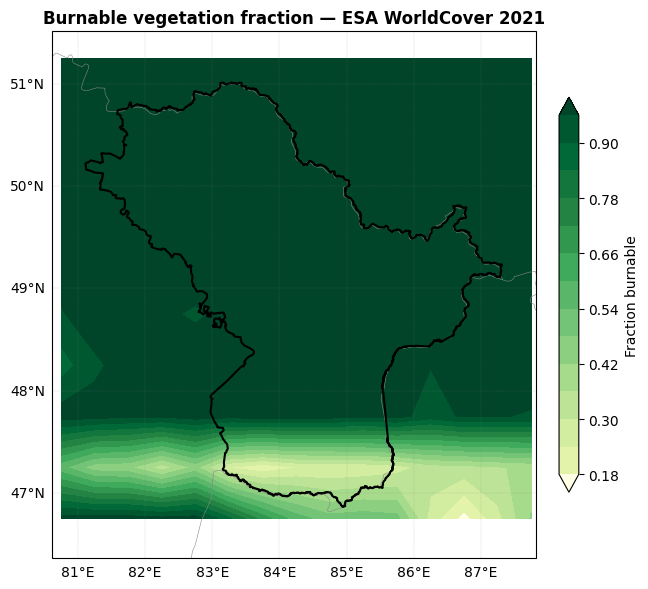

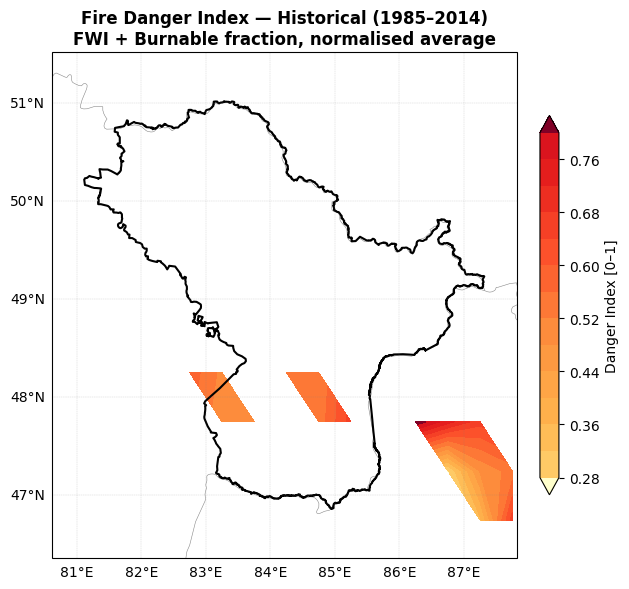

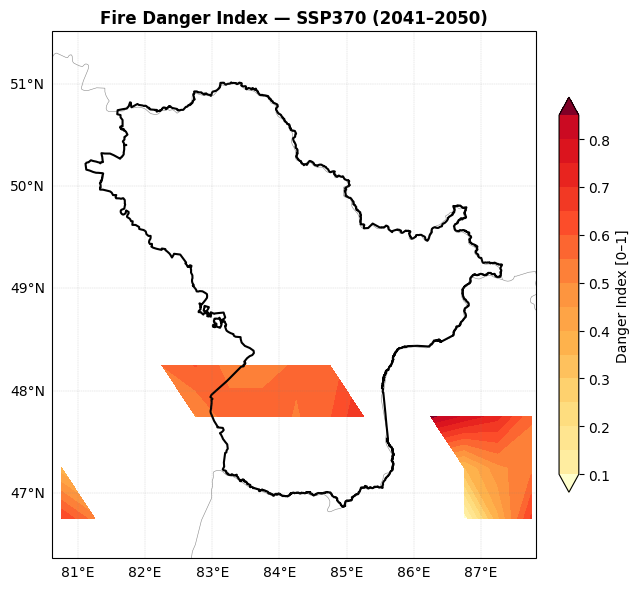

In [ ]:
def plot_kaz_field(data, lats, lons, boundary_gdf, title,
                   cmap='YlOrRd', vmin=None, vmax=None,
                   cbar_label='', save_path=None):
    fig, ax = plt.subplots(figsize=(12, 6),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='#888888')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888888')
    lon2d, lat2d = np.meshgrid(lons, lats)
    cf = ax.contourf(lon2d, lat2d, data, transform=ccrs.PlateCarree(),
                      cmap=cmap, vmin=vmin, vmax=vmax, levels=15, extend='both')
    plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02,
                  shrink=0.75, label=cbar_label)
    boundary_gdf.boundary.plot(ax=ax, transform=ccrs.PlateCarree(),
                                color='black', linewidth=1.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                       color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


plot_kaz_field(
    burn_frac, lats, lons, eko_dissolved,
    title='Burnable vegetation fraction — ESA WorldCover 2021',
    cmap='YlGn', vmin=0, vmax=1, cbar_label='Fraction burnable',
    save_path=results_dir / f'{region_id}_BurnableFraction.png'
)

plot_kaz_field(
    danger_hist.values, lats, lons, eko_dissolved,
    title=(f'Fire Danger Index — Historical ({HIST_START}–{HIST_END})\n'
           f'FWI + Burnable fraction, normalised average'),
    cmap='YlOrRd', vmin=0, vmax=1, cbar_label='Danger Index [0–1]',
    save_path=results_dir / f'{region_id}_DangerIndex_hist.png'
)

plot_kaz_field(
    danger_fut.values, lats, lons, eko_dissolved,
    title=(f'Fire Danger Index — {FUTURE_SCENARIO.upper()} '
           f'({FUTURE_START}–{FUTURE_END})'),
    cmap='YlOrRd', vmin=0, vmax=1, cbar_label='Danger Index [0–1]',
    save_path=results_dir / f'{region_id}_DangerIndex_{FUTURE_SCENARIO}.png'
)

## Plot vulnerability indicators

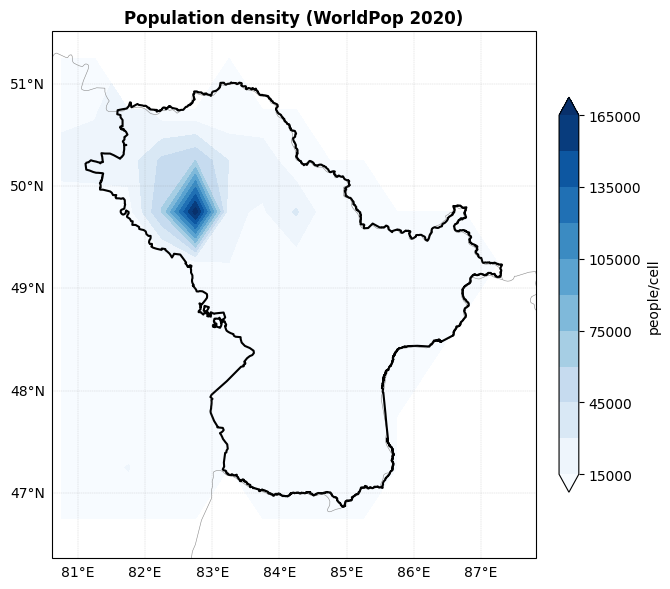

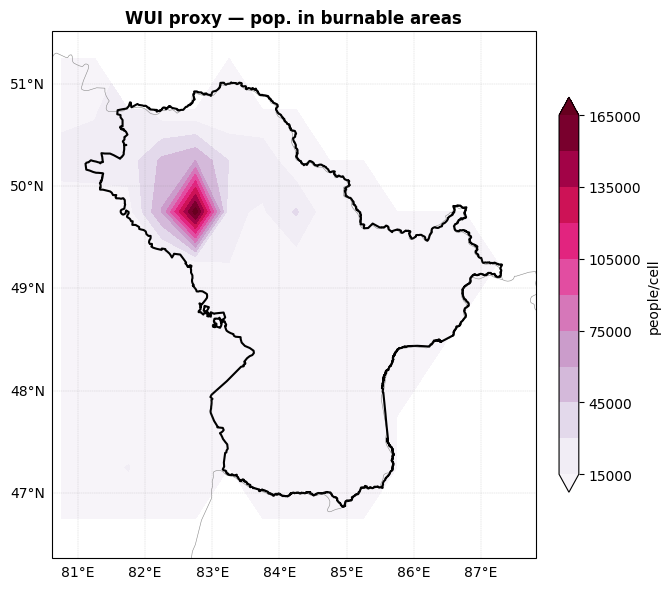

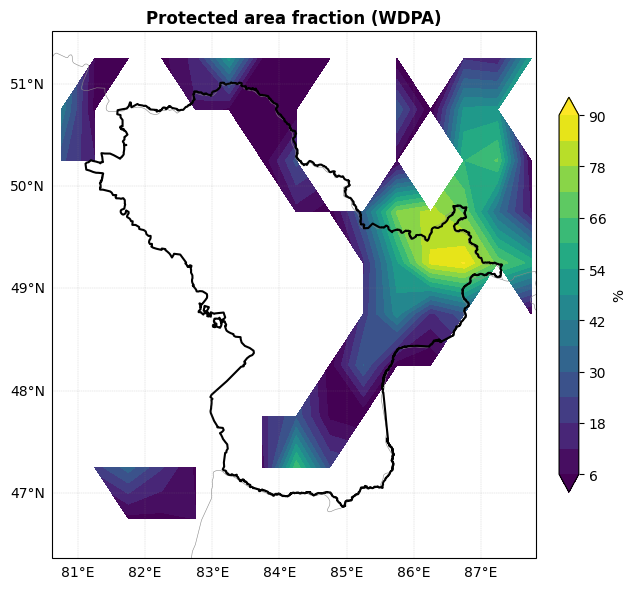

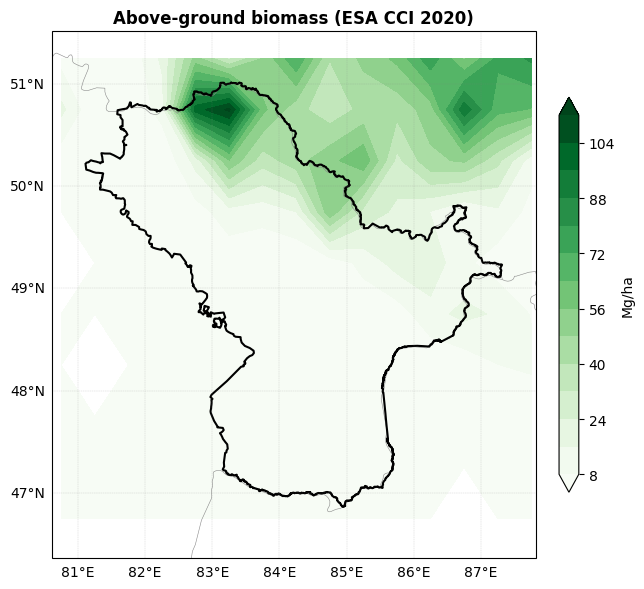

In [41]:
vuln_config = {
    'pop_density': ('Population density (WorldPop 2020)',   'Blues',  'people/cell'),
    'wui_proxy':   ('WUI proxy — pop. in burnable areas',   'PuRd',   'people/cell'),
    'prot_area':   ('Protected area fraction (WDPA)',        'viridis','%'),
    'biomass':     ('Above-ground biomass (ESA CCI 2020)',   'Greens', 'Mg/ha'),
}

for var, (title, cmap, unit) in vuln_config.items():
    if var not in risk_hist:
        continue
    plot_kaz_field(
        risk_hist[var].values, lats, lons, eko_dissolved,
        title=title, cmap=cmap, cbar_label=unit,
        save_path=results_dir / f'{region_id}_Vuln_{var}.png'
    )

## Pareto Risk Analysis

Following the EFFIS methodology, the Pareto front identifies grid cells
with the highest overall risk profile across all selected indicators.
Cells on the Pareto front cannot be outperformed by any other cell on
every indicator simultaneously.

**To focus on a specific risk dimension** (e.g. ecological only),
remove indicators from `pareto_vars` below before running.

In [42]:
def run_pareto(risk_ds, vuln_vars, label):
    pareto_vars = ['danger'] + vuln_vars
    df = risk_ds[pareto_vars].to_dataframe().reset_index()
    df_valid = df.dropna(subset=pareto_vars).copy()

    if df_valid.empty:
        print(f'  [{label}] No valid cells — check danger threshold.')
        return None, None, None

    print(f'  [{label}] Valid cells: {len(df_valid)} / {len(df)}')

    sense_max = [max] * len(pareto_vars)
    sense_min = [min] * len(pareto_vars)

    mask_hi = paretoset(df_valid[pareto_vars], sense=sense_max)
    mask_lo = paretoset(df_valid[pareto_vars], sense=sense_min)

    print(f'  Highest risk cells: {mask_hi.sum()}')
    print(f'  Lowest  risk cells: {mask_lo.sum()}')

    return df_valid[mask_hi], df_valid[mask_lo], df_valid


print('Running Pareto analysis...')
hi_hist, lo_hist, df_hist = run_pareto(risk_hist, vuln_vars, 'historical')
hi_fut,  lo_fut,  df_fut  = run_pareto(risk_fut,  vuln_vars, f'{FUTURE_SCENARIO}')

Running Pareto analysis...
  [historical] Valid cells: 4 / 150
  Highest risk cells: 3
  Lowest  risk cells: 3
  [ssp370] Valid cells: 8 / 150
  Highest risk cells: 6
  Lowest  risk cells: 5


## Risk maps

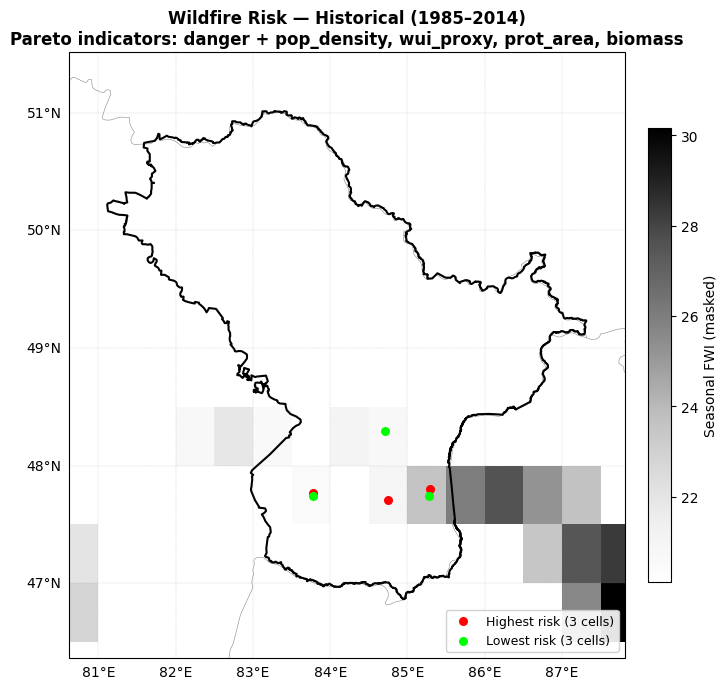

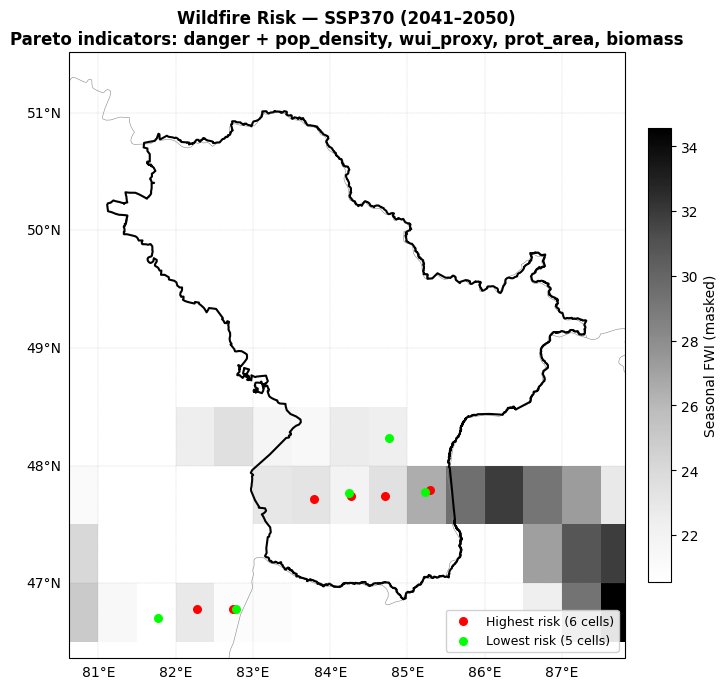

In [49]:
def plot_risk_map(fwi_arr, hi_df, lo_df, lats, lons, boundary_gdf,
                  title, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 7),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#888888')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888888')

    lon2d, lat2d = np.meshgrid(lons, lats)
    mesh = ax.pcolormesh(lon2d, lat2d, fwi_arr, cmap='Greys',
                          transform=ccrs.PlateCarree(), zorder=1)
    plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02,
                  shrink=0.75, label='Seasonal FWI (masked)')

    rng = np.random.default_rng(42)
    jitter = 0.05 

    if hi_df is not None and len(hi_df):
        ax.scatter(hi_df['lon'] + rng.uniform(-jitter, jitter, len(hi_df)),
                   hi_df['lat'] + rng.uniform(-jitter, jitter, len(hi_df)),
                   s=30, color='red',
                   label=f'Highest risk ({len(hi_df)} cells)',
                   transform=ccrs.PlateCarree(), zorder=3)
    if lo_df is not None and len(lo_df):
        ax.scatter(lo_df['lon'] + rng.uniform(-jitter, jitter, len(lo_df)),
                   lo_df['lat'] + rng.uniform(-jitter, jitter, len(lo_df)),
                   s=30, color='lime',
                   label=f'Lowest risk ({len(lo_df)} cells)',
                   transform=ccrs.PlateCarree(), zorder=3)

    boundary_gdf.boundary.plot(ax=ax, transform=ccrs.PlateCarree(),
                                color='black', linewidth=1.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                       color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


plot_risk_map(
    fwi_hist_masked.values, hi_hist, lo_hist,
    lats, lons, eko_dissolved,
    title=(f'Wildfire Risk — Historical ({HIST_START}–{HIST_END})\n'
           f'Pareto indicators: danger + {", ".join(vuln_vars)}'),
    save_path=results_dir / f'{region_id}_FireRisk_hist.png'
)

plot_risk_map(
    fwi_fut_masked.values, hi_fut, lo_fut,
    lats, lons, eko_dissolved,
    title=(f'Wildfire Risk — {FUTURE_SCENARIO.upper()} ({FUTURE_START}–{FUTURE_END})\n'
           f'Pareto indicators: danger + {", ".join(vuln_vars)}'),
    save_path=results_dir / f'{region_id}_FireRisk_{FUTURE_SCENARIO}.png'
)

## Historical vs future risk change


Risk change summary (ssp370):
  Historical high-risk cells : 3
  Future high-risk cells     : 6
  Retained high-risk cells   : 3
  Newly high-risk (future)   : 3
  No longer high-risk        : 0


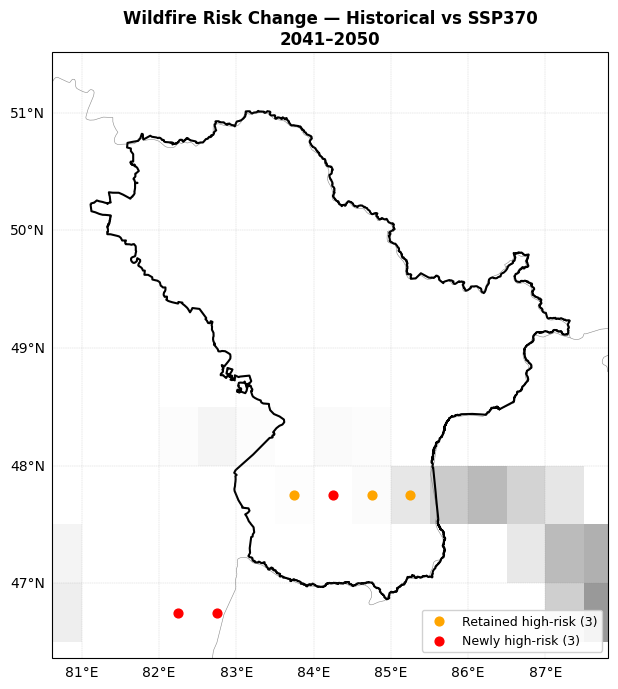

In [44]:
if hi_hist is not None and hi_fut is not None:
    hist_cells = set(zip(hi_hist['lat'].round(3), hi_hist['lon'].round(3)))
    fut_cells  = set(zip(hi_fut['lat'].round(3),  hi_fut['lon'].round(3)))
    new_risk   = fut_cells - hist_cells
    lost_risk  = hist_cells - fut_cells
    retained   = hist_cells & fut_cells

    print(f'\nRisk change summary ({FUTURE_SCENARIO}):')
    print(f'  Historical high-risk cells : {len(hist_cells)}')
    print(f'  Future high-risk cells     : {len(fut_cells)}')
    print(f'  Retained high-risk cells   : {len(retained)}')
    print(f'  Newly high-risk (future)   : {len(new_risk)}')
    print(f'  No longer high-risk        : {len(lost_risk)}')

    fig, ax = plt.subplots(figsize=(12, 7),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#888888')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888888')

    lon2d, lat2d = np.meshgrid(lons, lats)
    ax.pcolormesh(lon2d, lat2d, fwi_hist_masked.values,
                   cmap='Greys', alpha=0.4,
                   transform=ccrs.PlateCarree(), zorder=1)

    def scatter_set(cells, color, label):
        if cells:
            lts, lns = zip(*cells)
            ax.scatter(lns, lts, s=40, color=color, label=label,
                       transform=ccrs.PlateCarree(), zorder=3)

    scatter_set(retained,  'orange', f'Retained high-risk ({len(retained)})')
    scatter_set(new_risk,  'red',    f'Newly high-risk ({len(new_risk)})')
    scatter_set(lost_risk, 'green',  f'No longer high-risk ({len(lost_risk)})')

    eko_dissolved.boundary.plot(ax=ax, transform=ccrs.PlateCarree(),
                                 color='black', linewidth=1.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                       color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.set_title(
        f'Wildfire Risk Change — Historical vs {FUTURE_SCENARIO.upper()}\n'
        f'{FUTURE_START}–{FUTURE_END}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(results_dir / f'{region_id}_FireRisk_change_{FUTURE_SCENARIO}.png',
                 dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

In [45]:
risk_hist.to_netcdf(data_dir / 'risk_hist.nc')
risk_fut.to_netcdf(data_dir / 'risk_fut.nc')
print('Done.')

Done.


## Results summary

Outputs saved to `results/`:
- `KAZ_EKO_BurnableFraction.png` — ESA WorldCover burnable fraction map
- `KAZ_EKO_DangerIndex_hist.png` — Historical fire danger index
- `KAZ_EKO_DangerIndex_{scenario}.png` — Future fire danger index
- `KAZ_EKO_Vuln_*.png` — Vulnerability indicator maps
- `KAZ_EKO_FireRisk_hist.png` — Historical Pareto risk map
- `KAZ_EKO_FireRisk_{scenario}.png` — Future Pareto risk map
- `KAZ_EKO_FireRisk_change_{scenario}.png` — Risk change map

**Interpretation notes for East Kazakhstan Region:**
- East Kazakhstan has diverse terrain (Altai Mountains, steppe, taiga)
  with genuine fire risk in forested and steppe zones.
- The 0.5° ISIMIP3b grid gives ~3–4 cells across the region — results
  are indicative at regional scale, not site-specific.
- With only GFDL-ESM4, model uncertainty is not captured. Run all 5 GCMs
  for robust risk assessment.
- If WDPA and ESA CCI Biomass layers were skipped, the Pareto analysis
  reflects only population-based vulnerability. Download those datasets
  and rerun for a complete assessment.